In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np
import joblib
model_path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/power_model/'

est_tp2_tp4 = joblib.load(model_path + "tp2_tp4/unified_power_model_tp2_tp4.joblib")
est_tp8 = joblib.load(model_path + "tp8/unified_power_model_tp8.joblib")

def infer(model, tp, freq, tokens_prefill=None, tokens_decode=None):
    FEATURE_COLS = [
        'model',
        'prefill_batch_size', 'prefill_input_len_sum', 'prefill_input_len_mean', 'prefill_input_len_std',
        'decode_batch_size', 'decode_input_len_sum', 'decode_input_len_mean', 'decode_input_len_std',
        'tp_degree', 'freq_mhz'
    ]

    X = pd.DataFrame([{
        "prefill_batch_size": len(tokens_prefill) if tokens_prefill else 0,
        "prefill_input_len_sum": sum(tokens_prefill) if tokens_prefill else 0,
        "prefill_input_len_mean": float(np.mean(tokens_prefill)) if tokens_prefill else 0,
        "prefill_input_len_std": float(np.std(tokens_prefill)) if tokens_prefill else 0,
        "decode_batch_size": len(tokens_decode) if tokens_decode else 0,
        "decode_input_len_sum": sum(tokens_decode) if tokens_decode else 0,
        "decode_input_len_mean": float(np.mean(tokens_decode)) if tokens_decode else 0,
        "decode_input_len_std": float(np.std(tokens_decode)) if tokens_decode else 0,
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct"
    }], columns=FEATURE_COLS)

    # otherwise assume sklearn pipeline
    pred = model.predict(X)
    return float(pred[0])


def compute_power_w(df_power_sub: pd.DataFrame):
    energy_j = 0.0
    gpu_power_cols = [col for col in df_power_sub.columns if col.startswith("GPU_") and col.endswith("_power_w")]

    for col in gpu_power_cols:
        energy_j += np.trapezoid(df_power_sub[col], df_power_sub['Timestamp'])

    duration = df_power_sub['Timestamp'].max() - df_power_sub['Timestamp'].min()
    if duration == 0:
        return 0.0, 0.0
    return (energy_j / duration), energy_j


def plot_cumulative_compute_energy(path, tp_degree, freq):
    if tp_degree == 2 or tp_degree == 4:
        pre_p = est_tp2_tp4
    else:
        pre_p = est_tp8

                
    df_decode = pd.read_csv(path + '/engine_0.csv')
    df_power = pd.read_csv(path + '/power_log.csv')

    df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
    df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
    df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
    df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)
    df_decode['start_times'] = df_decode['now']

    real_energy = []
    predicted_energy = []
    skip_indices = []
    for row in df_decode.itertuples():
        if len(row.num_prompt_tokens_reqs_evald) == 0 or \
            len(row.max_num_generation_tokens_iter_evald) == 0 or \
            len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
            pd.isna(row.iter_lat) or \
            len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
            continue
        else:
            start_time = row.start_times
            end_time = row.start_times + row.iter_lat
            df_power_sub = df_power[(df_power['Timestamp'] >= start_time+0.1) & (df_power['Timestamp'] <= end_time+0.1)]
            p, energy = compute_power_w(df_power_sub)
            if energy == 0.0:
                skip_indices.append(row.Index)
                continue
            real_energy.append(energy)

            prefill_lens = []
            decode_lens = []
            
            for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
                if gen_tok == 1:
                    # This is a prefill request
                    prefill_lens.append(prompt_len)
                else:
                    # This is a decode request
                    # Total KV cache size = prompt_len + gen_tokens
                    decode_lens.append(prompt_len + gen_tok)

            if len(prefill_lens) > 0 and len(decode_lens) > 0:
                power_w = infer(model=pre_p, tp=tp_degree, freq=freq, tokens_prefill=prefill_lens, tokens_decode=decode_lens)
            elif len(prefill_lens) > 0 and len(decode_lens) == 0:
                power_w = infer(model=pre_p, tp=tp_degree, freq=freq, tokens_prefill=prefill_lens, tokens_decode=None)
            elif len(prefill_lens) == 0 and len(decode_lens) > 0:
                power_w = infer(model=pre_p, tp=tp_degree, freq=freq, tokens_prefill=None, tokens_decode=decode_lens)

            predicted_energy_j = power_w * row.iter_lat
            predicted_energy.append(predicted_energy_j)
            
            # print(f"Index: {row.Index}, Real P: {p:.2f}, Predicted P: {power_w:.2f}, Prefill Lens: {len(prefill_lens)}, Decode Lens: {len(decode_lens)}")

    # print MAPE
    real_energy = np.array(real_energy[:-1])
    predicted_energy = np.array(predicted_energy[:-1])
    mape = np.mean(np.abs((real_energy - predicted_energy) / real_energy)) * 100
    print(f"Decode Energy Model MAPE: {mape}%") 

    #plot cumulative energies
    plt.figure(figsize=(16, 6))
    plt.plot(np.cumsum(real_energy), label='Real Energy (J)')
    plt.plot(np.cumsum(predicted_energy), label='Predicted Energy (J)')
    plt.xlabel('Batch Index')
    plt.ylabel('Cumulative Energy')
    plt.title('Cumulative Real vs Predicted Energy Consumption')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


Decode Energy Model MAPE: 41.746420902149836%


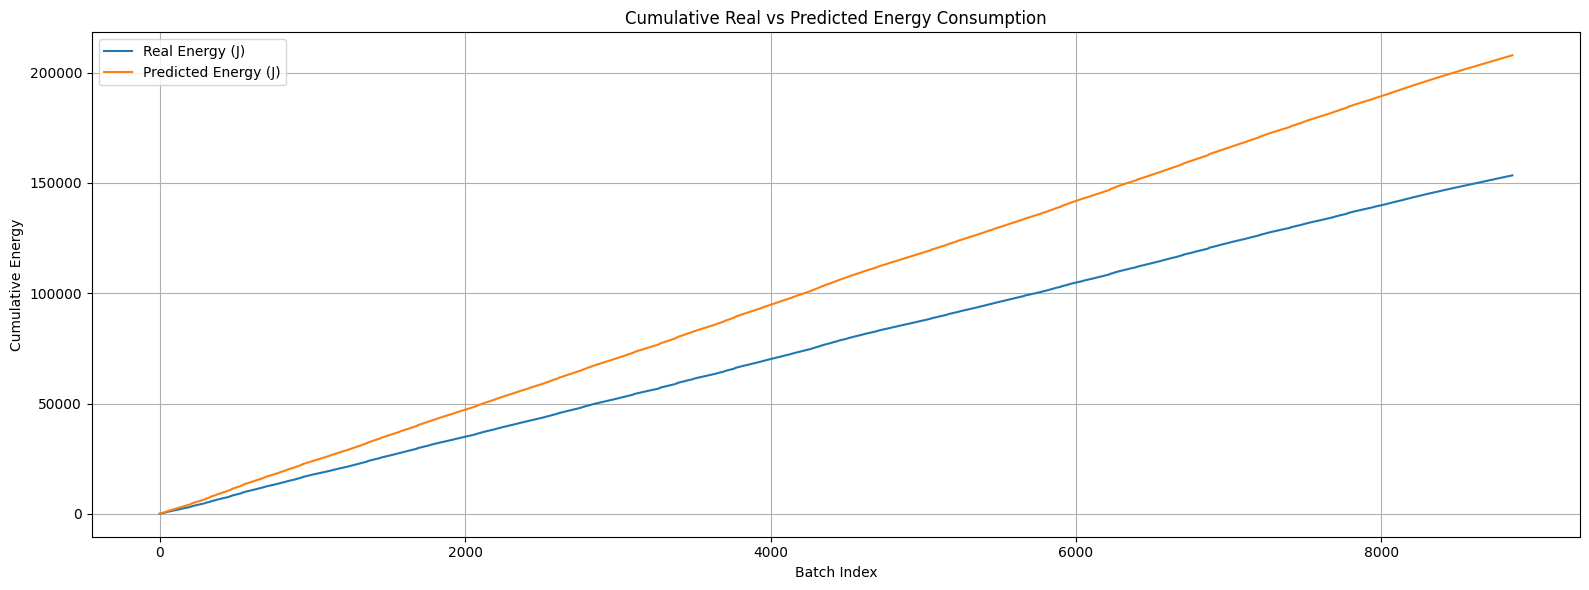

In [2]:
path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs_with_trace/TP2_1080_2RPS/prefill_and_decode_TP2_1080_2RPS'
freq = 1080
tp_degree = 2
plot_cumulative_compute_energy(path, tp_degree, freq)


Decode Energy Model MAPE: 56.9260946618535%


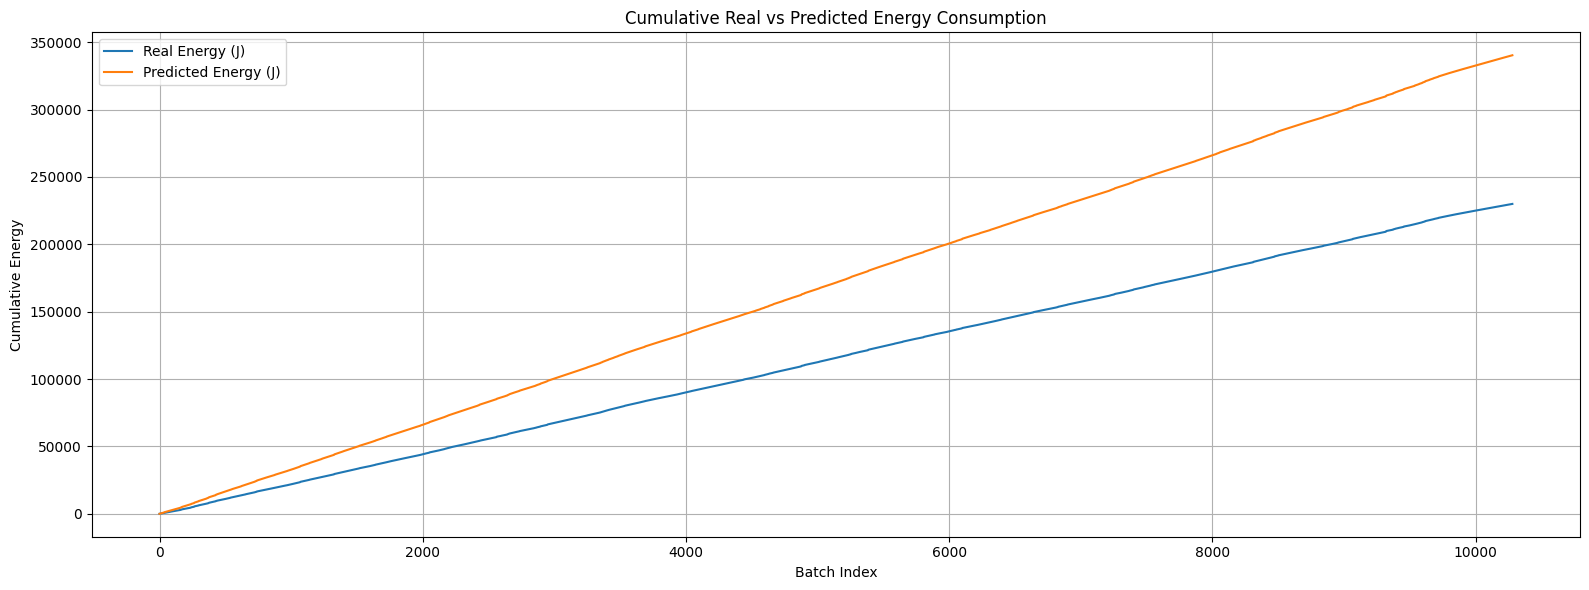

In [3]:
path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs_with_trace/TP2_1830_3RPS/prefill_and_decode'
freq = 1830
tp_degree = 2
plot_cumulative_compute_energy(path, tp_degree, freq)

Decode Energy Model MAPE: 88.08356883761088%


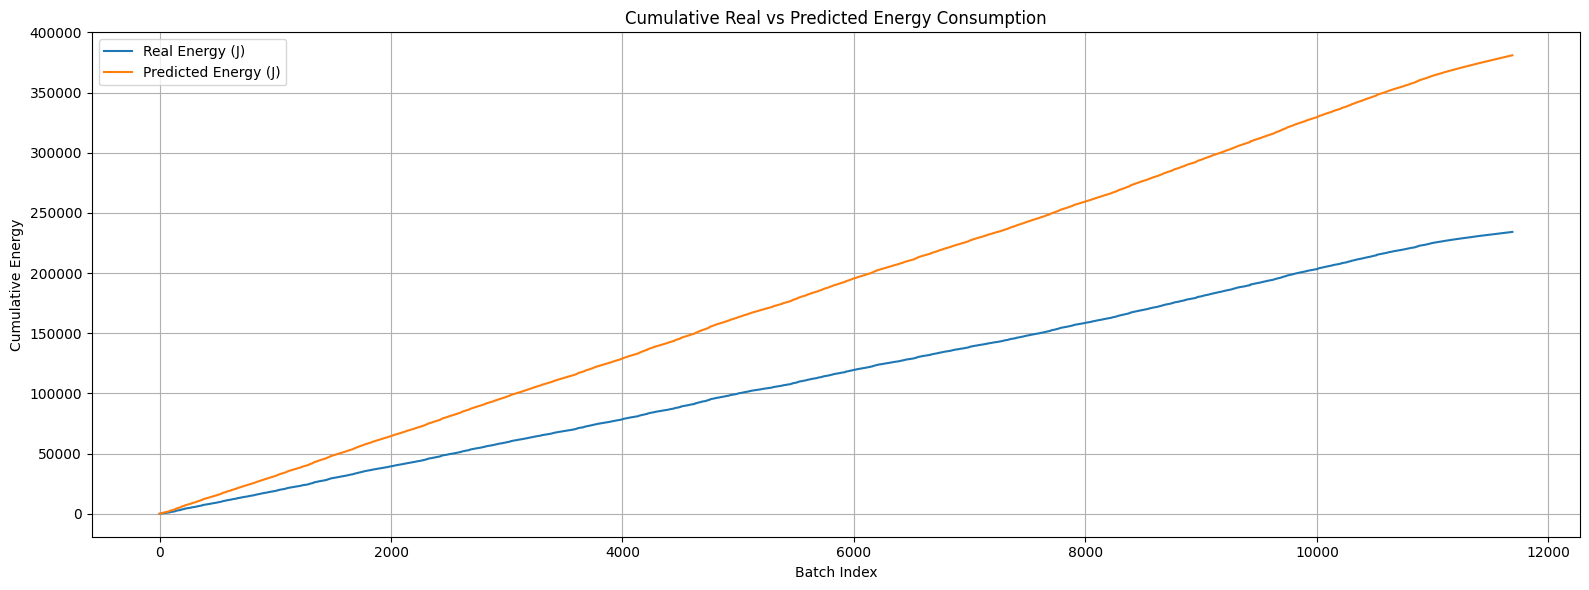

In [4]:
path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs_with_trace/TP4_1080_7RPS/prefill_and_decode'
freq = 1080
tp_degree = 4
plot_cumulative_compute_energy(path, tp_degree, freq)

Decode Energy Model MAPE: 87.41184737976349%


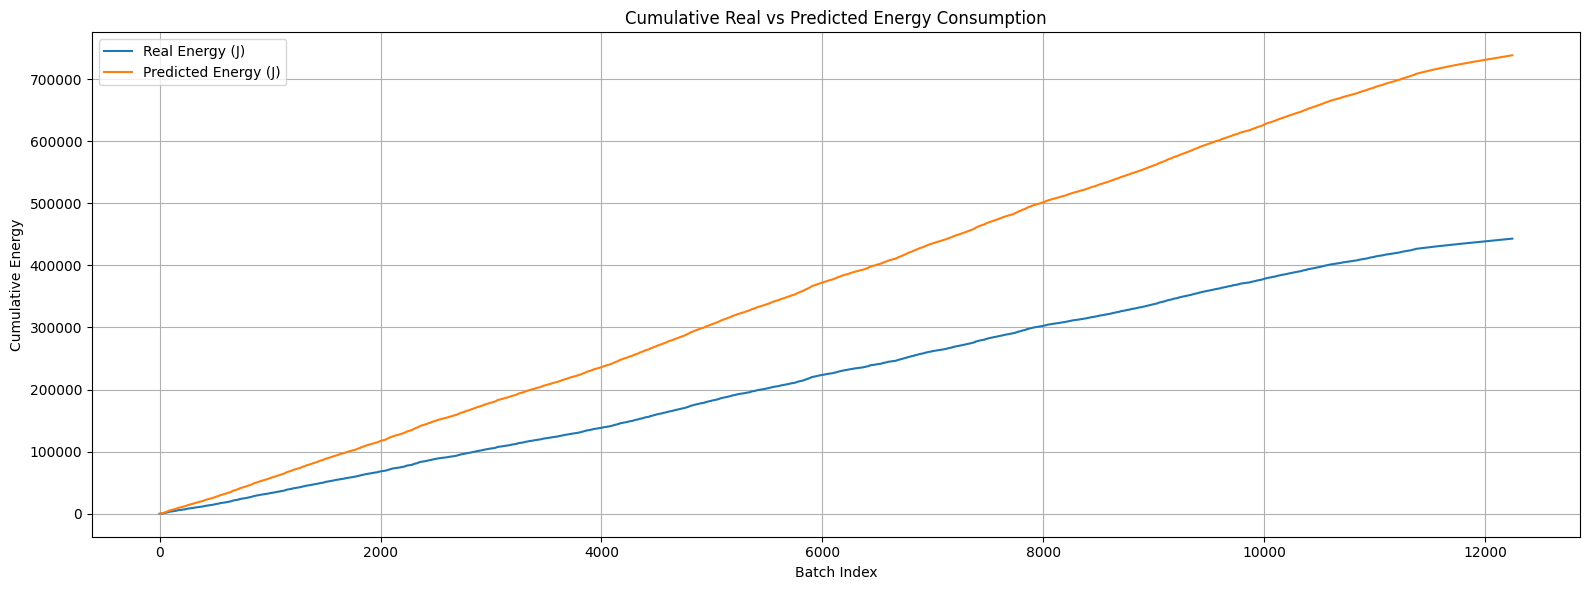

In [5]:
path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs_with_trace/TP4_1830_15RPS/prefill_and_decode'
freq = 1830
tp_degree = 4
plot_cumulative_compute_energy(path, tp_degree, freq)

Decode Energy Model MAPE: 86.74258796815349%


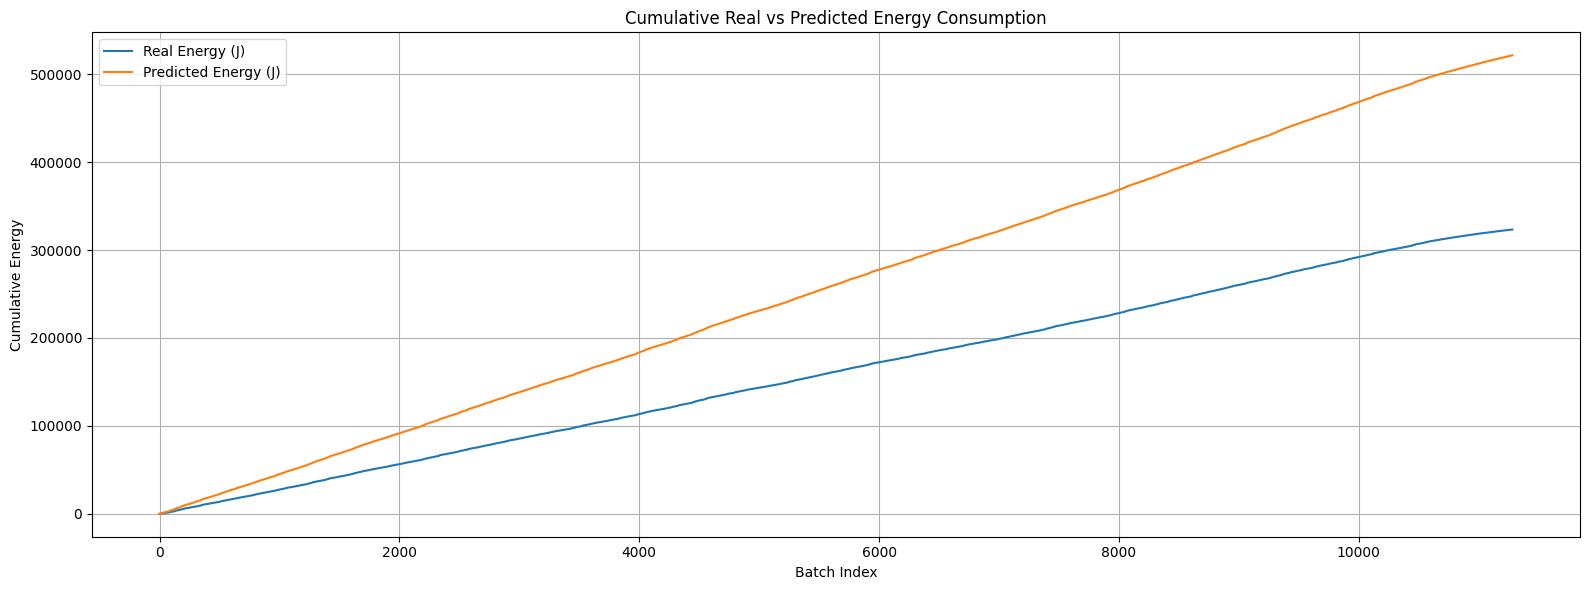

In [6]:
path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs_with_trace/TP8_780_7RPS/prefill_and_decode'
freq = 780
tp_degree = 8
plot_cumulative_compute_energy(path, tp_degree, freq)

Decode Energy Model MAPE: 53.54735872428294%


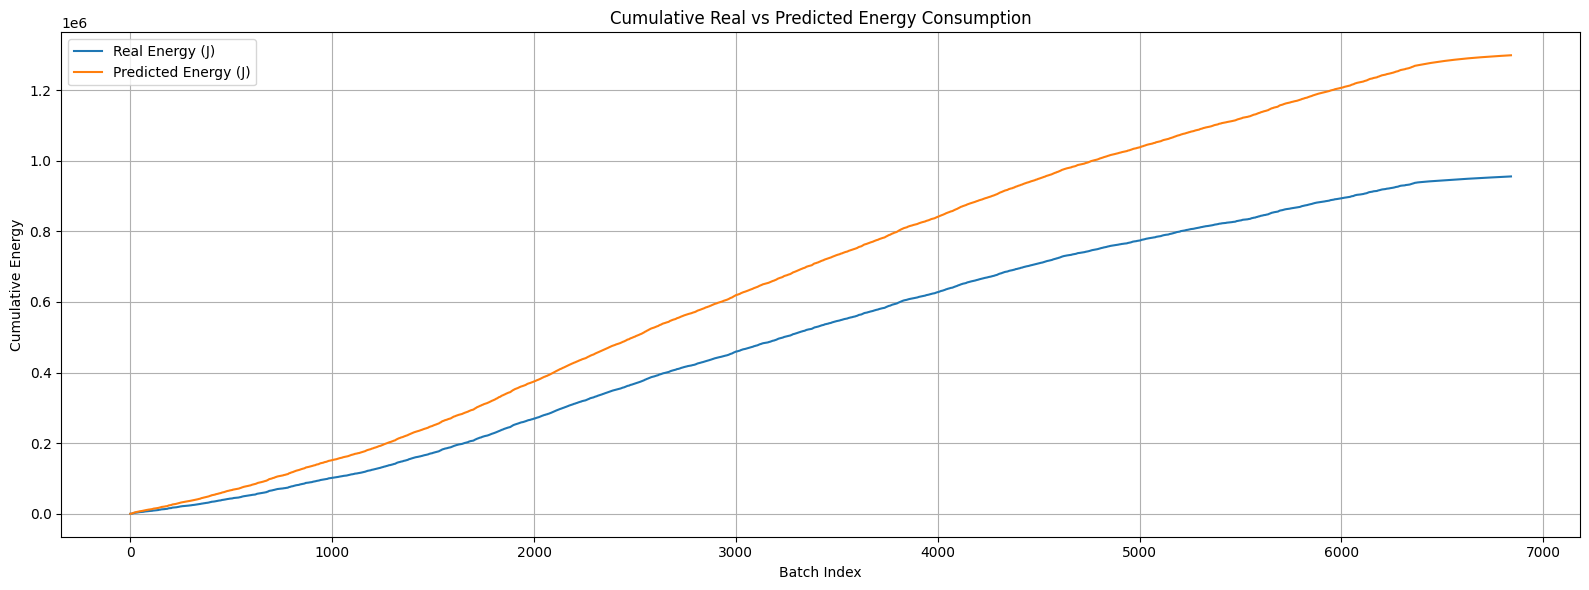

In [7]:
path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs_with_trace/TP8_1830_36RPS/prefill_and_decode'
freq = 1830
tp_degree = 8
plot_cumulative_compute_energy(path, tp_degree, freq)